# REINFORCE / Monte Carlo Policy Gradient

### Configuration

In [ ]:
import os
import sys
import subprocess
import zipfile
import json
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# set globals
USER = 'josemarquezjaramillo'
REPO = 'crypto-rl-portfolio'
DATASET = 'dataset_v1'

In [ ]:
# pull repo - colab starts uninitialized
os.system(f'git clone https://github.com/{USER}/{REPO}')
os.chdir(REPO)

# install requirements
req_result = subprocess.run('pip install -r requirements-data.txt', shell=True, capture_output=True, text=True)

print("=== STDOUT ===")
print(req_result.stdout.strip())   # remove extra blank lines
print("\n=== STDERR ===")
print(req_result.stderr.strip())

print(f"\nExit code: {req_result.returncode}")

=== STDOUT ===
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 21.8 MB/s eta 0:00:00

=== STDERR ===


Exit code: 0


In [ ]:
# extract data
with zipfile.ZipFile(f"data/{DATASET}.zip", "r") as zip_ref:
    zip_ref.extractall(".")

#### Imports

In [ ]:
sys.path.append(os.getcwd())

In [ ]:
# library imports
import pandas as pd
import numpy as np

# local imports
from agents import *
from environment import *
from tests import *

# pytorch
import torch
# get cuda
print(torch.cuda.is_available())

True


#### Read Data

In [ ]:
def read_asset_lists(subset):
    data = []
    with open(f"{DATASET}/{subset}_asset_lists.jsonl") as f:
        for line in f:
            json_object = json.loads(line.strip())
            data.append(json_object)
    return data

def read_index(subset):
  return pd.read_parquet(f"{DATASET}/{subset}_index.parquet")

def read_fwd_returns(subset):
  return np.load(f"{DATASET}/{subset}_fwd_returns.npz")

def read_obs_tensors(subset):
  return np.load(f"{DATASET}/{subset}_obs_tensors.npz")

metadata = json.load(open(f"{DATASET}/metadata.json"))
dev_asset_list = read_asset_lists('dev')
dev_index = read_index('dev')
dev_tensors = read_obs_tensors('dev')

In [ ]:
def get_obs(idx_tbl, tensors, idx):
  date = idx_tbl['date'][idx].strftime('t_%Y-%m-%d')
  return tensors[date]

In [ ]:
data_ = get_obs(dev_index, dev_tensors, 0)

In [ ]:
data_.shape

(10, 4, 60)

## Run Example Code (Environment)

In [ ]:
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from data.dataset_loader import load_exported_dataset
from data.dataset_backend import DatasetBackend
from environment.environment import PortfolioEnv, EnvConfig
from agents.base_agent import *

In [ ]:
def softmax_cap_continuous(z, max_alloc, eps=1e-8):
    """
    Closed-form continuously differentiable softmax cap.
    Ensures max softmax <= max_alloc (conservative bound).
    No loops, no argmax.
    """

    # sort logits to get top-2 (differentiable w.r.t z)
    z_sorted, _ = torch.sort(z, dim=-1, descending=True)
    a = z_sorted[..., 0]           # largest logit
    b = z_sorted[..., 1]           # second largest
    g = a - b                      # logit gap

    # constant determined by desired cap
    k = -torch.log((1 - max_alloc) / max_alloc)  # scalar

    # closed-form temperature
    T = g / (k + eps)              # (batch,)
    T = T.clamp(min=1.0)           # temperature can't shrink (keeps behavior smooth)

    # reshape T for broadcasting
    T = T.unsqueeze(-1)

    # return capped softmax
    return torch.softmax(z / T, dim=-1)

class RNN(nn.Module):
    def __init__(self, input_size=40, hidden_size=64, output_size=10, max_alloc=0.3):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.max_alloc = torch.tensor(max_alloc)

    def forward(self, x):
        # x: (batch, 10, 4, 60)  <-- if you feed this raw shape
        # We’ll rearrange it to (batch, 60, 40)

        # Move timestep to axis 1 (so we get seq_len = 60)
        x = x.permute(0, 3, 1, 2)   # (batch, 60, 10, 4)

        # Flatten feature dims (10 × 4 = 40)
        x = x.reshape(x.shape[0], x.shape[1], -1)  # (batch, 60, 40)

        # RNN forward
        out, _ = self.rnn(x)        # (batch, 60, hidden_size)
        out = out[:, -1, :]         # take final timestep
        out = self.fc(out)          # (batch, output_size)
        # out = torch.softmax(out, dim=-1) # sum to 1
        out = softmax_cap_continuous(out, self.max_alloc)
        return out

In [ ]:
# ------------------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------------------
print("\n[1/6] Loading dataset artifacts...")
ds = load_exported_dataset("dataset_v1", split="dev")
print(f"  ✓ Loaded {len(ds.dates())} days from dataset_v1/dev")

# ------------------------------------------------------------------------
# 2. Create Backend Adapters
# ------------------------------------------------------------------------
print("\n[2/6] Creating data backends...")

# Training backend (train_core split)
backend_train = DatasetBackend(ds, split_tag_filter="train_core")
print(f"  ✓ Training backend: {len(backend_train.dates())} days")

# Validation backend (all validation windows in dev split)
# Note: Not all validation windows may be present in the dev split
import pandas as pd
idx = pd.read_parquet("dataset_v1/dev_index.parquet")
val_tags = [tag for tag in idx['split_tag'].unique() if tag.startswith('val_window_')]

if val_tags:
    backend_val = DatasetBackend(ds, split_tag_filter=val_tags)
    print(f"  ✓ Validation backend: {len(backend_val.dates())} days ({len(val_tags)} windows)")
else:
    # Fallback: use a small subset of train_core for validation demo
    backend_val = DatasetBackend(ds, split_tag_filter="train_core")
    print(f"  ✓ Validation backend: {len(backend_val.dates())} days (using train_core subset)")

# ------------------------------------------------------------------------
# 3. Initialize Environments
# ------------------------------------------------------------------------
print("\n[3/6] Initializing environments...")

# Training environment
cfg_train = EnvConfig(
    split="train",
    cost_rate=0.001,
    turnover_cap=0.30,
    start_date="2018-09-01",
    end_date="2022-12-31",
    random_seed=42,
)
env_train = PortfolioEnv(cfg_train, backend_train)
print(f"  ✓ Training env: {len(env_train._dates)} days")


[1/6] Loading dataset artifacts...
  ✓ Loaded 1948 days from dataset_v1/dev

[2/6] Creating data backends...
  ✓ Training backend: 1848 days
  ✓ Validation backend: 100 days (5 windows)

[3/6] Initializing environments...
  ✓ Training env: 1503 days


In [ ]:
# Training environment
cfg_val = EnvConfig(
    split="val",
    cost_rate=0.001,
    turnover_cap=0.30,
    start_date="2023-01-01",
    end_date="2024-12-31",
    random_seed=42,
)
env_val = PortfolioEnv(cfg_val, backend_val)

In [ ]:
class PolicyGrad(BaseAgent):
  def __init__(self, cfg, env, epsilon=0, epsilon_decay = 0, max_alloc = 0.35, device='cuda'):
    super().__init__(cfg, env)
    self.device=device
    self.action_history = []
    self.reward_history = []
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay
    self.nn = RNN(input_size=40, hidden_size=64, output_size=10, max_alloc=max_alloc).to(self.device)
    self.max_alloc = max_alloc

  def random_policy(self):
    n = 10
    # Step 1: draw from Dirichlet (guarantees positivity, sums to 1)
    p = torch.distributions.Dirichlet(torch.ones(n)).sample().to(self.device)

    # Step 2: cap values above max_alloc
    excess = p.clamp(min=0)  # just defensive, p>=0 anyway
    over_mask = excess > self.max_alloc
    overflow = (excess[over_mask] - self.max_alloc).sum()

    p[over_mask] = self.max_alloc

    # Step 3: redistribute overflow to entries below max_alloc
    # Only distribute to non-capped indices
    under_mask = ~over_mask
    redistribute_space = under_mask.sum()

    if redistribute_space == 0:
        # corner case: all entries hit cap exactly → uniform under cap
        return torch.full((n,), 1.0/n, device=self.device)

    # distribute overflow uniformly (keeps randomness, stays simple)
    p[under_mask] += overflow / redistribute_space

    # Step 4: slight re-normalization (to remove numerical drift)
    p = p / p.sum()

    return p

  def select_action(self, obs, deterministic=False):
      features = torch.as_tensor(obs['features'], dtype=torch.float32, device=self.device)
      if not deterministic:
        random = np.random.random()
        if random < self.epsilon:
          action = self.random_policy()
        else:
          action = self.nn(features.unsqueeze(0))[0]
      else:
        action = self.nn(features.unsqueeze(0))[0] # add batch dim for forward-pass

      # action = cap_softmax(action, self.max_alloc)

      self.action_history.append(action)

      return action.cpu().detach().numpy()

  def apply_transaction_threshold(self, prev_action, curr_action):
    adj_action = action
    return adj_action

  def update(self, obs, action, reward, next_obs, done):
    # pass
    new_close = torch.tensor(next_obs['features'][:,0,-2], dtype=torch.float32, device=self.device)**-1
    reward = torch.dot(self.action_history[-1], new_close)
    return reward

  def on_episode_start(self):
    pass
  def on_episode_end(self):
    pass
  def load(self, path):
    pass
  def save(self, path):
    pass
  # def get_buffer(self):
  #   return ReplayBuffer(self.replay_buffer)

In [ ]:
class PolicyGrad2(BaseAgent):
    def __init__(self, cfg, env, epsilon=0, epsilon_decay=0, max_alloc=0.35, device='cuda'):
        super().__init__(cfg, env)
        self.device = device
        self.action_history = []   # store actions
        self.logprob_history = []  # store log-probs for REINFORCE
        self.reward_history = []   # store rewards
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.nn = RNN(input_size=40, hidden_size=64, output_size=10, max_alloc=max_alloc).to(self.device)
        self.max_alloc = max_alloc


    # ----------------------------------------------------------------------
    # Random policy unchanged (used for epsilon exploration)
    # ----------------------------------------------------------------------
    def random_policy(self):
        n = 10
        p = torch.distributions.Dirichlet(torch.ones(n)).sample().to(self.device)
        over_mask = p > self.max_alloc
        overflow = (p[over_mask] - self.max_alloc).sum()
        p[over_mask] = self.max_alloc
        under_mask = ~over_mask
        p[under_mask] += overflow / under_mask.sum()
        p = p / p.sum()
        return p


    # ----------------------------------------------------------------------
    # MINIMAL CHANGE #1: return differentiable action + log_prob
    # ----------------------------------------------------------------------
    def select_action(self, obs, deterministic=False):
        features = torch.as_tensor(obs['features'], dtype=torch.float32, device=self.device)

        if not deterministic and np.random.random() < self.epsilon:
            # epsilon exploration (no gradient)
            action = self.random_policy()
            # fake log-prob = 0, won't contribute to gradient
            log_prob = torch.tensor(0.0, device=self.device)
        else:
            # NN outputs a probability distribution over allocations
            probs = self.nn(features.unsqueeze(0))[0]   # (10,)

            # REINFORCE requires sampling from the policy distribution
            dist = torch.distributions.Categorical(probs)
            idx = dist.sample()
            log_prob = dist.log_prob(idx)

            # convert index back into a one-hot allocation vector
            action = torch.zeros_like(probs)
            action[idx] = 1.0

        # store BOTH action and log-prob
        self.action_history.append(action)
        self.logprob_history.append(log_prob)

        return action.cpu().detach().numpy()


    # ----------------------------------------------------------------------
    # MINIMAL CHANGE #2: compute reward only; do NOT compute gradients here
    # ----------------------------------------------------------------------
    def update(self, obs, action, reward, next_obs, done):
        new_close = torch.tensor(next_obs['features'][:,0,-2], dtype=torch.float32, device=self.device)**-1
        reward = torch.dot(self.action_history[-1], new_close)
        self.reward_history.append(reward)
        return reward


    # ----------------------------------------------------------------------
    # MINIMAL CHANGE #3: compute REINFORCE loss at episode end
    # ----------------------------------------------------------------------
    def on_episode_end(self):
        # Discounted returns not used here — simple episodic REINFORCE
        R = torch.prod(torch.tensor(self.reward_history, device=self.device))

        # loss = -sum(logprob_t * R)
        loss = -(torch.stack(self.logprob_history).sum() * R)

        # clean up for next episode, but return loss for backprop
        self.action_history.clear()
        self.logprob_history.clear()
        self.reward_history.clear()
        self.epsilon *= (1-self.epsilon_decay)

        return loss
    def load(self, path):
      pass
    def save(self, path):
      pass

In [ ]:
EPISODES = 500
agent = PolicyGrad2(cfg_train, env_train, device='cuda', epsilon=0.1, epsilon_decay=0.1)

optimizer = torch.optim.Adam(agent.nn.parameters(), lr=0.001)
train_rewards_history = []
val_rewards_history = []

for epoch in tqdm(range(EPISODES)):
  done = False
  obs = agent.env.reset()
  reward = 1
  while not done:
    action = agent.select_action(obs)
    next_obs, _, done, _ = agent.env.step(action)
    r = agent.update(None, action, None, next_obs, done)
    reward *= r.item()
    obs = next_obs
    if done:
      break
  train_rewards_history.append(reward)
  loss = agent.on_episode_end()
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  0%|          | 0/500 [00:00<?, ?it/s]

In [7]:
import pandas as pd
import seaborn as sns

<Axes: >

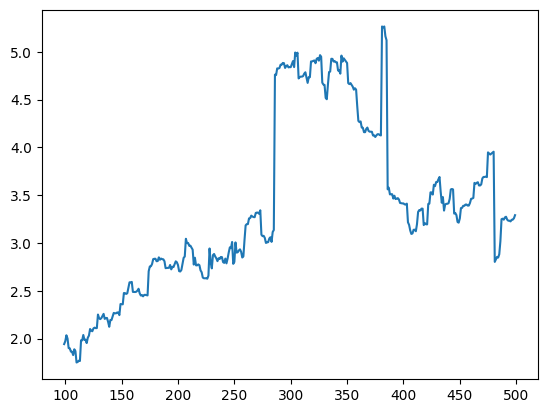

In [17]:
import pandas as pd
rolling_mean = pd.Series(train_rewards_history).rolling(window=100).mean()
sns.lineplot(rolling_mean)